<a href="https://colab.research.google.com/github/Plumz17/PP_FinalProject2/blob/main/PP_FinalProject2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pattern Recognition Project - Plant Leaf Disease Recognition using Traditional ML Feature Extraction Methods
Arranged by:
*   Anders Emmanuel Tan (24/541351/PA/22964)
*   Danar Fathurahman (24/538200/PA/22828)

Description: Pada projek ini, kami akan menyusun pipeline lengkap menggunakan teknik-teknik ekstraksi fitur tradisional untuk mendeteksi adanya penyakit pada daun tanaman.

## 0. Loading the Dataset
Description:

In [1]:
# Import Important Libraries
import requests, os, zipfile, io, cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [2]:
# Import Dataset
URL = "https://data.mendeley.com/public-api/zip/ncg7kk3gwx/download/1"
os.makedirs("/content/medicinal_plant", exist_ok=True)

r = requests.get(URL, stream=True, headers={"User-Agent": "Mozilla/5.0"})
total = int(r.headers.get("content-length", 0))

with open("/content/medicinal_plant.zip", "wb") as f, tqdm(total=total, unit="B", unit_scale=True) as bar:
  for chunk in r.iter_content(chunk_size=1024*1024):
    f.write(chunk)
    bar.update(len(chunk))

100%|██████████| 8.05G/8.05G [04:56<00:00, 27.2MB/s]


In [3]:
# Extract outer zip
with zipfile.ZipFile("/content/medicinal_plant.zip") as z:
  z.extractall("/content/medicinal_plant")

# Extract inner zip
inner_zip = "/content/medicinal_plant/data/Medicinal Plant Leaf Disease Dataset/Medicinal_leaf_dataset.zip"
with zipfile.ZipFile(inner_zip) as z:
  z.extractall("/content/medicinal_plant/data")

print("Extraction complete!")

Extraction complete!


## 1. Preprocessing


In [5]:
DATA_DIR = "/content/medicinal_plant/data/Medicinal_leaf_dataset"
IMG_SIZE = (224, 224)
class_names = sorted(os.listdir(DATA_DIR))
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
images = []
labels = []
for class_name in tqdm(class_names, desc="Loading"):
  class_path = os.path.join(DATA_DIR, class_name)
  for img_file in os.listdir(class_path):
    img = cv2.imread(os.path.join(class_path, img_file))
    if img is None:
      continue
    #Resize image to the suggested size
    img = cv2.resize(img, IMG_SIZE)
    #Convert Color Model to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images.append(img)
    labels.append(class_to_idx[class_name])

# Normalize each pixel to 0 - 1.0 and convert to numpy array
images = np.array(images, dtype=np.float32) / 255.0
labels = np.array(labels)

print(f"Images : {images.shape}")
print(f"Labels : {labels.shape}")
print(f"Classes: {class_names}")

Loading: 100%|██████████| 12/12 [05:06<00:00, 25.53s/it]


Images : (2547, 224, 224, 3)
Labels : (2547,)
Classes: ['Kalanchoe_Healthy', 'Kalanchoe_Web_Blight', 'Kalanchoe_Yellow', 'Kalanchoe_Yellow_Blight', 'Neem_Healthy', 'Neem_Spot', 'Neem_Web_Blight', 'Neem_Yellow', 'Tulsi_Downy_Mildew', 'Tulsi_Healthy', 'Tulsi_Web_Blight', 'Tulsi_Yellow_Spot']


In [6]:
def show(before, after, title2= "Enhanced"): # Helper function to check the before and after of the processing
  plt.figure(figsize=(10,5))

  # Show original
  plt.subplot(1,2,1)
  plt.imshow(before, cmap='gray', vmin=0, vmax=255) #vmin and max to preserve original image's contrast
  plt.title("Original")
  plt.axis("off")

  # Show processed
  plt.subplot(1,2,2)
  plt.imshow(after, cmap='gray', vmin=0, vmax=255)
  plt.title(title2)
  plt.axis("off")

  plt.show()

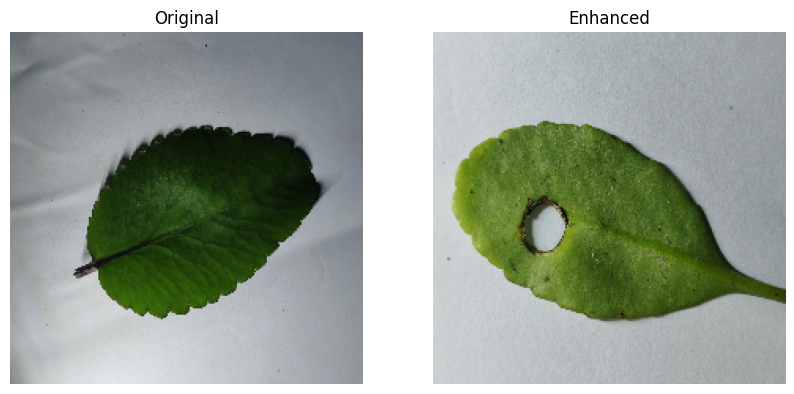

In [15]:
show(images[0], images[209])